# Exploratory Data Analysis

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
# read in bolus data
bolus_path = "CSCI413Project/cleaned data/Bolus_Data_Aggregated.csv"
bolus_df = pd.read_csv(bolus_path)
bolus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53289 entries, 0 to 53288
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subjectID   53289 non-null  int64  
 1   bolus_ts    53289 non-null  object 
 2   bolus_dose  53289 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.2+ MB


In [3]:
# read in short basal data
short_path = "CSCI413Project/cleaned data/Short_Data_Aggregated.csv"
short_df = pd.read_csv(short_path)
short_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9452 entries, 0 to 9451
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subjectID   9452 non-null   int64  
 1   basal_ts    9452 non-null   object 
 2   basal_dose  9452 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 221.7+ KB


In [4]:
# read in all basal data
basal_path = "CSCI413Project/cleaned data/Basal_Data_Aggregated.csv"
basal_df = pd.read_csv(basal_path)
basal_df.drop(columns=["Unnamed: 0.4", "Unnamed: 0.3", "Unnamed: 0.2", "Unnamed: 0.1", "Unnamed: 0"], inplace=True)
basal_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31370 entries, 0 to 31369
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   subjectID   31370 non-null  int64  
 1   basal_ts    31370 non-null  object 
 2   basal_dose  31370 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 735.4+ KB


In [5]:
# read in glucose data
glucose_path = "CSCI413Project/cleaned data/Glucose_Data_Aggregated.csv"
glucose_df = pd.read_csv(glucose_path)
glucose_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40133 entries, 0 to 40132
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subjectID  40133 non-null  int64  
 1   bg_ts      40133 non-null  object 
 2   value      37108 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 940.7+ KB


In [6]:
# read in nutrition data
nutrition_path = "CSCI413Project/cleaned data/Nutrition_Data_Aggregated.csv"
nutrition_df = pd.read_csv(nutrition_path)
nutrition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1703466 entries, 0 to 1703465
Data columns (total 5 columns):
 #   Column     Dtype  
---  ------     -----  
 0   subjectID  int64  
 1   meal_ts    object 
 2   carbs_g    float64
 3   prot_g     float64
 4   fat_g      float64
dtypes: float64(3), int64(1), object(1)
memory usage: 65.0+ MB


In [7]:
# read in activity data
activity_path = "CSCI413Project/cleaned data/Activity_Data_Aggregated.csv"
activity_df = pd.read_csv(activity_path)
activity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37769 entries, 0 to 37768
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subjectID              37769 non-null  int64  
 1   activity_ts            37769 non-null  object 
 2   active_Kcal            37769 non-null  int64  
 3   step_count             37769 non-null  int64  
 4   distance_m             37769 non-null  float64
 5   active_time_s          37769 non-null  int64  
 6   motion_intensity_mean  37769 non-null  float64
 7   met                    37769 non-null  float64
 8   motion_intensity_max   37769 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 2.6+ MB


In [8]:
# read in sleep data
sleep_path = "CSCI413Project/cleaned data/Sleep_Data_Aggregated.csv"
sleep_df = pd.read_csv(sleep_path)
sleep_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26455 entries, 0 to 26454
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   subjectID                        26455 non-null  int64  
 1   sleep_ts                         26455 non-null  object 
 2   heart_rate                       26455 non-null  float64
 3   current_activity_type_intensity  26455 non-null  float64
 4   stress_level_value               26455 non-null  float64
 5   resting_heart_rate               26455 non-null  float64
 6   sleep_level                      26455 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.4+ MB


In [9]:
# turn glucose units from mmol/L to mg/dL so I can understand them
glucose_df["value"] *= 18
glucose_df.head()

,subjectID,bg_ts,value
0,2301,2023-10-01 00:00:00,193.200
1,2301,2023-10-01 01:00:00,262.125
2,2301,2023-10-01 02:00:00,NaN
3,2301,2023-10-01 03:00:00,NaN
4,2301,2023-10-01 04:00:00,NaN


In [10]:
# fill null glucose values with the average for that subject
glucose_averages = glucose_df.groupby("subjectID")["value"].mean()

for subject in glucose_averages.keys():
    subset = glucose_df[ glucose_df["subjectID"] == subject ]
    glucose_df.update(subset.fillna({"value": glucose_averages[subject]}))
    
glucose_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40133 entries, 0 to 40132
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   subjectID  40133 non-null  int64  
 1   bg_ts      40133 non-null  object 
 2   value      40133 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 940.7+ KB


In [11]:
# merge bolus and glucose data
bolus_bg_merged = pd.merge(bolus_df, glucose_df, left_on=["bolus_ts", "subjectID"], right_on=["bg_ts", "subjectID"], how="inner")
bolus_bg_merged.head()

,subjectID,bolus_ts,bolus_dose,bg_ts,value
0,2301,2023-11-10 12:00:00,2.360,2023-11-10 12:00:00,137.10
1,2301,2023-11-10 13:00:00,0.000,2023-11-10 13:00:00,141.45
2,2301,2023-11-10 14:00:00,0.239,2023-11-10 14:00:00,169.80
3,2301,2023-11-10 15:00:00,0.408,2023-11-10 15:00:00,184.95
4,2301,2023-11-10 16:00:00,0.340,2023-11-10 16:00:00,182.55


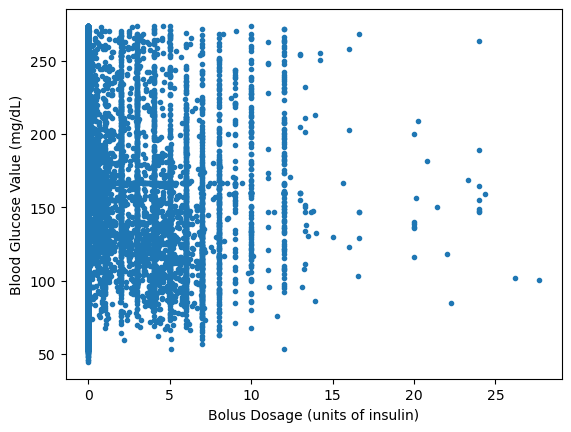

In [12]:
# graph bolus dose vs glucose
plt.plot(bolus_bg_merged["bolus_dose"], bolus_bg_merged["value"], '.')
plt.xlabel("Bolus Dosage (units of insulin)")
plt.ylabel("Blood Glucose Value (mg/dL)")
plt.show()

In [13]:
subjects = bolus_bg_merged["subjectID"].unique()

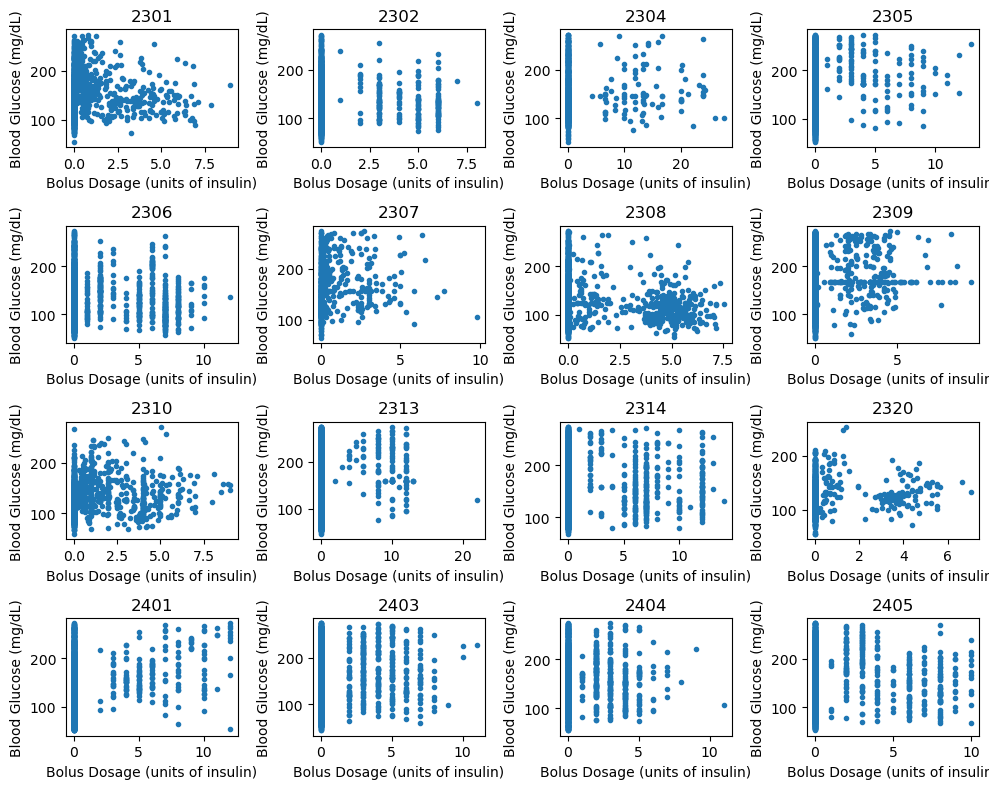

In [14]:
# graph separately for each individual
fig, axs = plt.subplots(4, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].plot(bolus_bg_merged["bolus_dose"][ bolus_bg_merged["subjectID"] == subjects[i] ],
                        bolus_bg_merged["value"][ bolus_bg_merged["subjectID"] == subjects[i] ], '.')
    axs[i//4, i%4].set_xlabel("Bolus Dosage (units of insulin)")
    axs[i//4, i%4].set_ylabel("Blood Glucose (mg/dL)")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

In [15]:
# average blood glucose by subject
glucose_df.groupby("subjectID")["value"].mean()

subjectID
2301    146.538475
2302    134.560448
2303    127.821041
2304    147.043720
2305    171.610335
2306    127.730123
2307    157.109448
2308    124.990486
2309    166.437415
2310    129.261282
2313    159.369674
2314    159.185811
2320    127.635957
2401    133.448931
2403    156.651446
2404    148.967359
2405    154.332461
Name: value, dtype: float64

In [16]:
# merge basal and glucose data
basal_bg_merged = pd.merge(basal_df, glucose_df, left_on=["basal_ts", "subjectID"], right_on=["bg_ts", "subjectID"], how="inner")
basal_bg_merged.head()

,subjectID,basal_ts,basal_dose,bg_ts,value
0,2301,2023-11-10 00:00:00,21.202,2023-11-10 00:00:00,146.538475
1,2301,2023-11-10 01:00:00,19.988,2023-11-10 01:00:00,146.538475
2,2301,2023-11-10 02:00:00,5.817,2023-11-10 02:00:00,270.000000
3,2301,2023-11-10 03:00:00,20.006,2023-11-10 03:00:00,271.200000
4,2301,2023-11-10 04:00:00,13.468,2023-11-10 04:00:00,248.550000


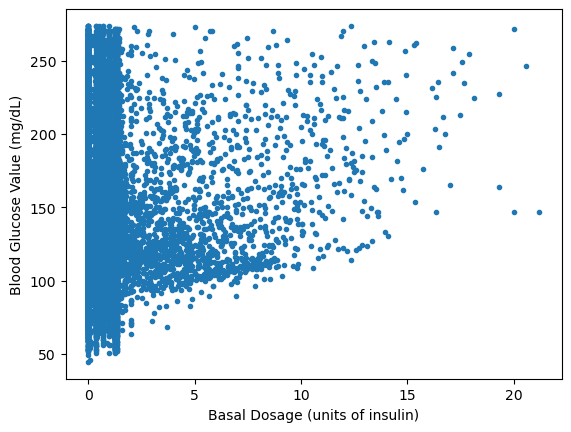

In [17]:
# graph basal dose vs glucose
plt.plot(basal_bg_merged["basal_dose"], basal_bg_merged["value"], '.')
plt.xlabel("Basal Dosage (units of insulin)")
plt.ylabel("Blood Glucose Value (mg/dL)")
plt.show()

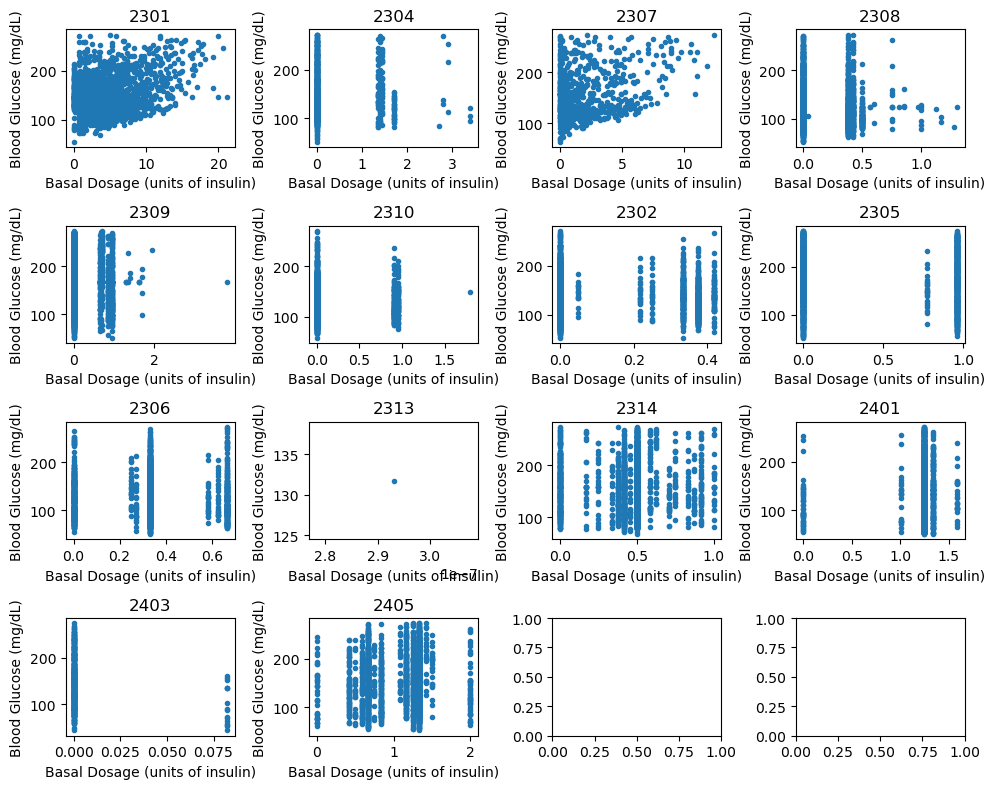

In [18]:
# graph separately for each individual
subjects = basal_bg_merged["subjectID"].unique()

fig, axs = plt.subplots(4, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].plot(basal_bg_merged["basal_dose"][ basal_bg_merged["subjectID"] == subjects[i] ],
                        basal_bg_merged["value"][ basal_bg_merged["subjectID"] == subjects[i] ], '.')
    axs[i//4, i%4].set_xlabel("Basal Dosage (units of insulin)")
    axs[i//4, i%4].set_ylabel("Blood Glucose (mg/dL)")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

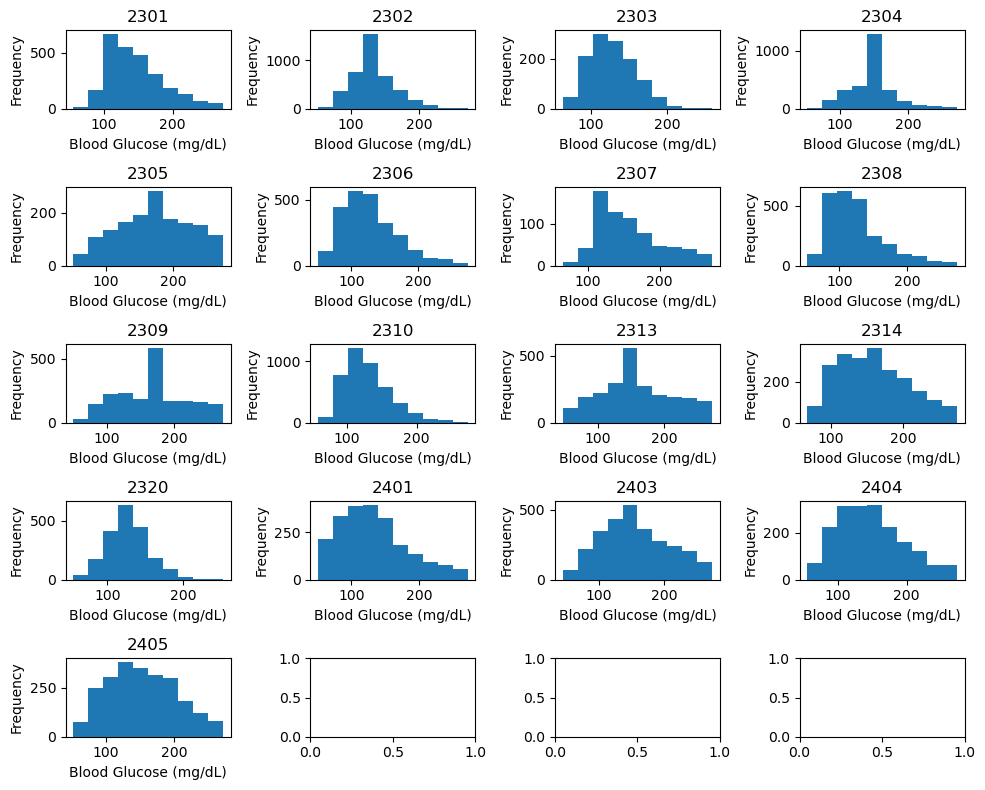

In [19]:
# histogram of glucose values by individual
subjects = glucose_df["subjectID"].unique()

fig, axs = plt.subplots(5, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].hist(glucose_df["value"][ glucose_df["subjectID"] == subjects[i] ])
    axs[i//4, i%4].set_xlabel("Blood Glucose (mg/dL)")
    axs[i//4, i%4].set_ylabel("Frequency")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

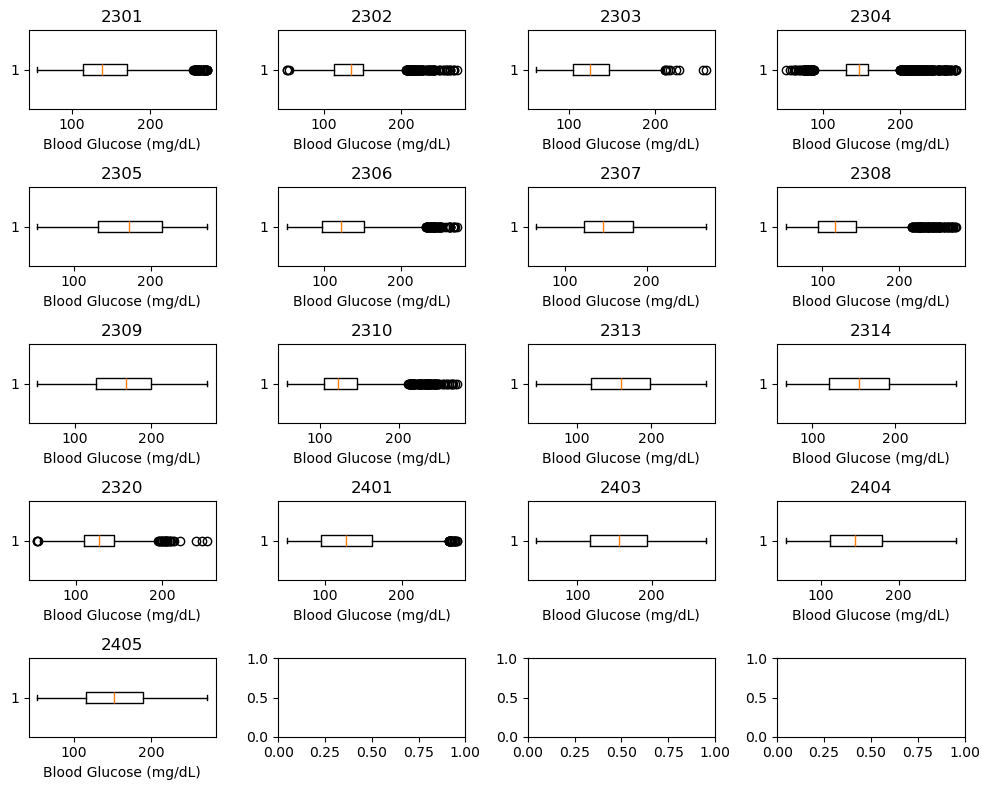

In [20]:
# scatter plot of glucose values by individual
fig, axs = plt.subplots(5, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].boxplot(glucose_df["value"][ glucose_df["subjectID"] == subjects[i] ], vert=False)
    axs[i//4, i%4].set_xlabel("Blood Glucose (mg/dL)")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

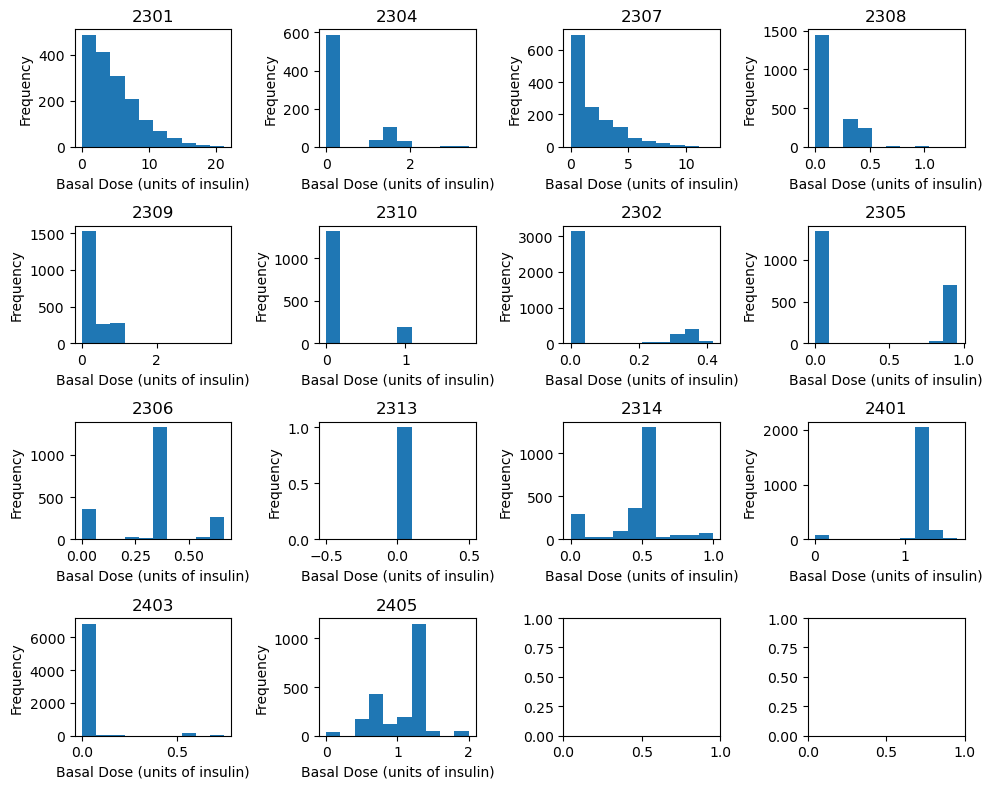

In [21]:
# histogram of basal values by individual
subjects = basal_df["subjectID"].unique()

fig, axs = plt.subplots(4, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].hist(basal_df["basal_dose"][ basal_df["subjectID"] == subjects[i] ])
    axs[i//4, i%4].set_xlabel("Basal Dose (units of insulin)")
    axs[i//4, i%4].set_ylabel("Frequency")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

In [22]:
# merge nutrition and glucose data
nutrition_bg_merged = pd.merge(nutrition_df, glucose_df, left_on=["meal_ts", "subjectID"], right_on=["bg_ts", "subjectID"], how="inner")
nutrition_bg_merged.head()

,subjectID,meal_ts,carbs_g,prot_g,fat_g,bg_ts,value
0,2301,2023-10-22 10:00:00,0.0,0.0,1.0,2023-10-22 10:00:00,162.000000
1,2301,2023-10-22 11:00:00,0.0,0.0,0.0,2023-10-22 11:00:00,164.850000
2,2301,2023-10-22 12:00:00,19.0,50.0,32.0,2023-10-22 12:00:00,192.109091
3,2301,2023-10-22 13:00:00,0.0,0.0,0.0,2023-10-22 13:00:00,250.800000
4,2301,2023-10-22 14:00:00,0.0,0.0,0.0,2023-10-22 14:00:00,172.500000


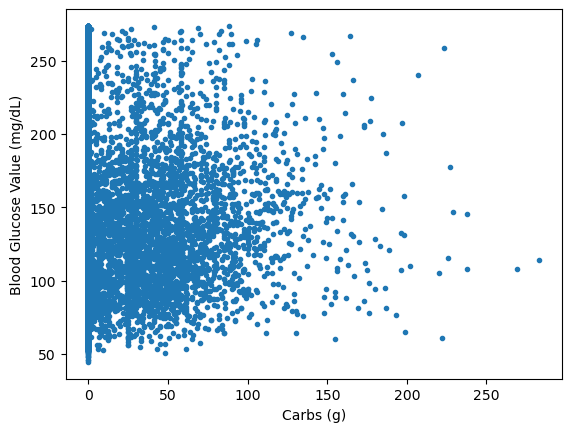

In [23]:
# graph carbs vs blood glucose
plt.plot(nutrition_bg_merged["carbs_g"], nutrition_bg_merged["value"], '.')
plt.xlabel("Carbs (g)")
plt.ylabel("Blood Glucose Value (mg/dL)")
plt.show()

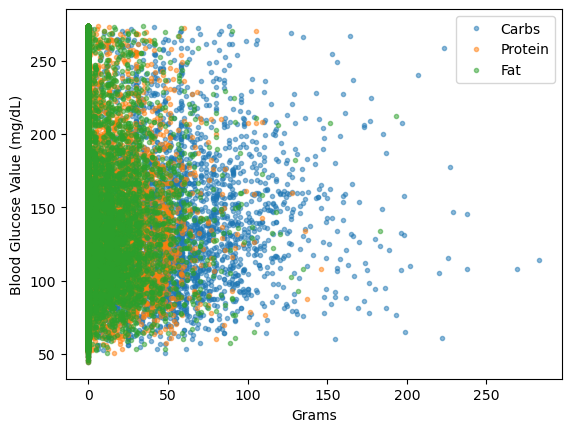

In [24]:
# graph carbs, protein, and fat vs blood glucose
plt.plot(nutrition_bg_merged["carbs_g"], nutrition_bg_merged["value"], '.', alpha=0.5)
plt.plot(nutrition_bg_merged["prot_g"], nutrition_bg_merged["value"], '.', alpha=0.5)
plt.plot(nutrition_bg_merged["fat_g"], nutrition_bg_merged["value"], '.', alpha=0.5)
plt.xlabel("Grams")
plt.ylabel("Blood Glucose Value (mg/dL)")
plt.legend(["Carbs", "Protein", "Fat"])
plt.show()

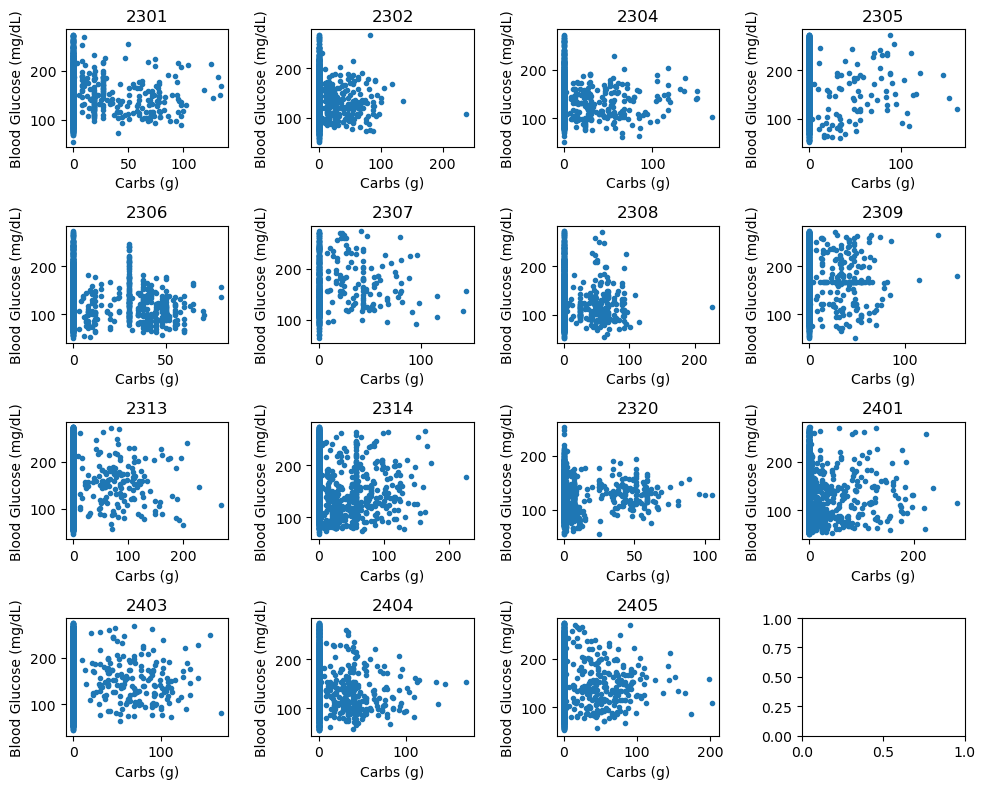

In [25]:
# graph separately for each individual
subjects = nutrition_bg_merged["subjectID"].unique()

fig, axs = plt.subplots(4, 4, figsize=(10, 8))

for i in range(len(subjects)):
    axs[i//4, i%4].plot(nutrition_bg_merged["carbs_g"][ nutrition_bg_merged["subjectID"] == subjects[i] ],
                        nutrition_bg_merged["value"][ nutrition_bg_merged["subjectID"] == subjects[i] ], '.')
    axs[i//4, i%4].set_xlabel("Carbs (g)")
    axs[i//4, i%4].set_ylabel("Blood Glucose (mg/dL)")
    axs[i//4, i%4].set_title(subjects[i])

plt.tight_layout()
plt.show()

In [26]:
# merge nutrition and bolus data
nutrition_bolus_merged = pd.merge(nutrition_df, bolus_df, left_on=["meal_ts", "subjectID"], right_on=["bolus_ts", "subjectID"], how="inner")
nutrition_bolus_merged.head()

,subjectID,meal_ts,carbs_g,prot_g,fat_g,bolus_ts,bolus_dose
0,2301,2023-11-10 12:00:00,19.0,50.0,32.0,2023-11-10 12:00:00,2.360
1,2301,2023-11-10 13:00:00,0.0,0.0,0.0,2023-11-10 13:00:00,0.000
2,2301,2023-11-10 14:00:00,0.0,0.0,0.0,2023-11-10 14:00:00,0.239
3,2301,2023-11-10 15:00:00,0.0,0.0,0.0,2023-11-10 15:00:00,0.408
4,2301,2023-11-10 16:00:00,0.0,0.0,0.0,2023-11-10 16:00:00,0.340


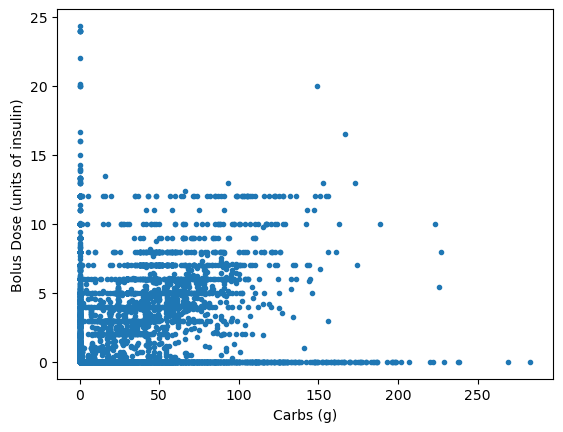

In [27]:
# graph carbs vs bolus
plt.plot(nutrition_bolus_merged["carbs_g"], nutrition_bolus_merged["bolus_dose"], '.')
plt.xlabel("Carbs (g)")
plt.ylabel("Bolus Dose (units of insulin)")
plt.show()

In [28]:
# merge sleep and glucose data
sleep_bg_merged = pd.merge(sleep_df, glucose_df, left_on=["sleep_ts", "subjectID"], right_on=["bg_ts", "subjectID"], how="inner")
sleep_bg_merged.head()

,subjectID,sleep_ts,heart_rate,current_activity_type_intensity,stress_level_value,resting_heart_rate,sleep_level,bg_ts,value
0,2301,2023-10-06 00:00:00,83.090909,20.363636,21.909091,0.0,0.0,2023-10-06 00:00:00,264.375
1,2301,2023-10-06 01:00:00,85.416667,38.666667,8.083333,0.0,0.0,2023-10-06 01:00:00,242.700
2,2301,2023-10-06 02:00:00,85.583333,22.333333,14.583333,0.0,0.0,2023-10-06 02:00:00,214.050
3,2301,2023-10-06 03:00:00,87.250000,29.166667,12.583333,0.0,0.0,2023-10-06 03:00:00,196.650
4,2301,2023-10-06 04:00:00,94.250000,37.833333,10.916667,0.0,0.0,2023-10-06 04:00:00,156.000


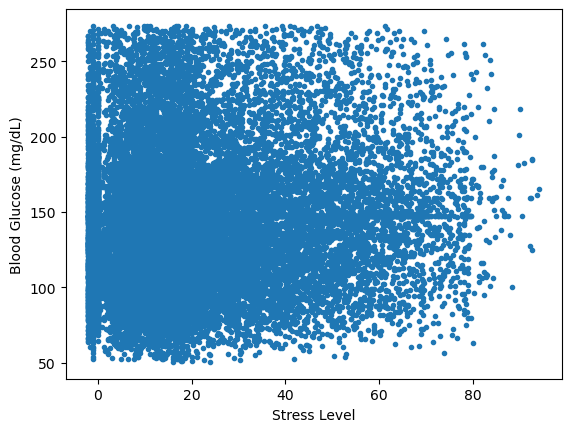

In [29]:
# graph stress vs blood glucose
plt.plot(sleep_bg_merged["stress_level_value"], sleep_bg_merged["value"], '.')
plt.xlabel("Stress Level")
plt.ylabel("Blood Glucose (mg/dL)")
plt.show()

In [30]:
# average blood glucose by sleep level
sleep_bg_merged.groupby("sleep_level")["value"].mean()

sleep_level
0.0    142.925488
1.0    137.959035
Name: value, dtype: float64

In [31]:
# merge activity and glucose data
activity_bg_merged = pd.merge(activity_df, glucose_df, left_on=["activity_ts", "subjectID"], right_on=["bg_ts", "subjectID"], how="inner")
activity_bg_merged.head()

,subjectID,activity_ts,active_Kcal,step_count,distance_m,active_time_s,motion_intensity_mean,met,motion_intensity_max,bg_ts,value
0,2301,2023-10-01 05:00:00,0,0,0.0,900,0.0,1.000000,2.0,2023-10-01 05:00:00,146.538475
1,2301,2023-10-01 06:00:00,0,0,0.0,3600,0.0,1.000000,4.0,2023-10-01 06:00:00,267.900000
2,2301,2023-10-01 07:00:00,0,0,0.0,3600,0.0,1.000000,4.0,2023-10-01 07:00:00,241.800000
3,2301,2023-10-01 08:00:00,1,19,13.7,3600,0.8,1.176039,4.0,2023-10-01 08:00:00,176.100000
4,2301,2023-10-01 09:00:00,0,0,0.0,3600,0.0,1.000000,5.0,2023-10-01 09:00:00,115.650000


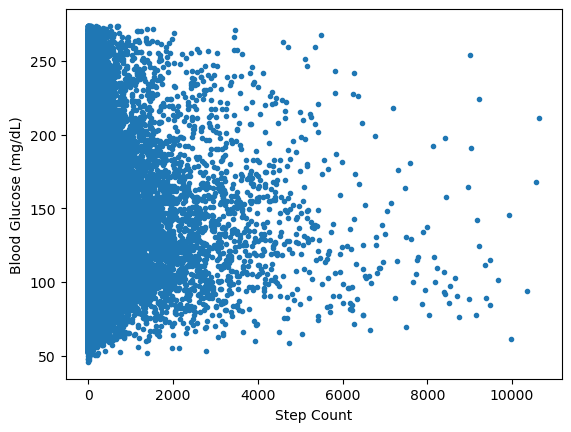

In [32]:
# graph step count vs blood glucose
plt.plot(activity_bg_merged["step_count"], activity_bg_merged["value"], '.')
plt.xlabel("Step Count")
plt.ylabel("Blood Glucose (mg/dL)")
plt.show()

In [33]:
# define function to calculate and display summary statistics for a numeric column
def display_stats(df, col):
    mean = df[col].mean()
    median = df[col].median()
    mode = df[col].mode()
    stdDev = df[col].std()
    maximum = df[col].max()
    minimum = df[col].min()

    print(f"Stats for {col}: \nMean: {mean} \nMedian: {median} \nMode: {mode} \nStandard Deviation: {stdDev} \nMax: {maximum} \nMin: {minimum}")

In [34]:
colsOfInterest = {"value":glucose_df, "bolus_dose":bolus_df, "basal_dose":basal_df, "carbs_g":nutrition_df,
                  "prot_g":nutrition_df, "fat_g":nutrition_df, "active_Kcal":activity_df, "step_count":activity_df,
                 "heart_rate":sleep_df, "stress_level_value":sleep_df}

for col in colsOfInterest.keys():
    display_stats(colsOfInterest[col], col)
    print()

Stats for value: 
Mean: 143.67340941267545 
Median: 136.5 
Mode: 0    147.04372
Name: value, dtype: float64 
Standard Deviation: 45.23389797581766 
Max: 273.59999999999997 
Min: 44.550000000000004

Stats for bolus_dose: 
Mean: 0.36331173412899476 
Median: 0.0 
Mode: 0    0.0
Name: bolus_dose, dtype: float64 
Standard Deviation: 1.5142472645065475 
Max: 27.7 
Min: 0.0

Stats for basal_dose: 
Mean: 0.6290489415421926 
Median: 0.0 
Mode: 0    0.0
Name: basal_dose, dtype: float64 
Standard Deviation: 1.4905532803526282 
Max: 21.202 
Min: 0.0

Stats for carbs_g: 
Mean: 0.11355146507180068 
Median: 0.0 
Mode: 0    0.0
Name: carbs_g, dtype: float64 
Standard Deviation: 2.9050881343677526 
Max: 283.2 
Min: 0.0

Stats for prot_g: 
Mean: 0.04517058162593207 
Median: 0.0 
Mode: 0    0.0
Name: prot_g, dtype: float64 
Standard Deviation: 1.2554637872471812 
Max: 146.0 
Min: 0.0

Stats for fat_g: 
Mean: 0.04589245103806005 
Median: 0.0 
Mode: 0    0.0
Name: fat_g, dtype: float64 
Standard Deviation: